# Gradient Analysis for Adaptive Step Solvers  

This notebook explores the accuracy and efficiency of gradient computation in adaptive step-size solvers. We analyze how different adjoint methods behave under varying step-size control strategies and assess their impact on gradient precision.  


In [1]:
import os
import sys

parent_dir = os.path.abspath("..")
sys.path.append(parent_dir)
os.environ["EQX_ON_ERROR"] = "nan"
from functools import partial
from typing import NamedTuple

import jax
import jax.numpy as jnp
import jax_cosmo as jc
import matplotlib.pyplot as plt
import numpy as np
from diffrax import (
    BacksolveAdjoint,
    ConstantStepSize,
    Dopri5,
    ODETerm,
    PIDController,
    RecursiveCheckpointAdjoint,
    Tsit5,
    diffeqsolve,
)
from jaxpm.painting import cic_paint_dx
from jaxpm.pm import linear_field, lpt, make_diffrax_ode
from tools.finite_difference import numerical_jvp
from tqdm import tqdm

jax.config.update("jax_enable_x64", True)

## Initialisation

### Generate Initial Conditions

This section initializes the simulation by defining the mesh resolution, box size, and cosmological parameters.  
We generate a uniform particle grid and use the linear matter power spectrum to compute initial density fluctuations.  
A white noise field is created and filtered to match the expected power spectrum, yielding the starting conditions for the simulation.


In [3]:
mesh_shape = [64, 64, 64]
box_size = [512.0, 512.0, 512.0]
snapshots = jnp.array([0.2, 0.5, 1.0])

omega_c = 0.25
sigma8 = 0.8
cosmo = jc.Planck15(Omega_c=omega_c, sigma8=sigma8)

k = jnp.logspace(-4, 1, 128)
pk = jc.power.linear_matter_power(cosmo, k)


def pk_fn(x):
    return jnp.interp(x.reshape([-1]), k, pk).reshape(x.shape)


# Create initial conditions
initial_conditions = linear_field(mesh_shape, box_size, pk_fn, seed=jax.random.PRNGKey(0))

### Gradient Computation for Symplectic Solvers

This section defines the gradient computation approach for symplectic solvers such as SemiImplicitEuler and FastPM LeapFrog.  

- **LPT Initialization**: The `run_lpt` function initializes particle displacements using first-order Lagrangian Perturbation Theory (LPT).  
- **N-body Evolution**: The `run_nbody` function advances the system using a symplectic solver. It supports different adjoint methods for computing gradients:  
  - **Checkpoint Adjoint**: Uses recursive checkpointing to balance memory and computational cost.  
  - **Reverse Adjoint**: Uses reverse-mode differentiation to propagate gradients efficiently.  


In [4]:
class Params(NamedTuple):
    Omega_c: float
    sigma8: float


@jax.jit
def run_lpt(params, ic):
    cosmo = jc.Planck15(Omega_c=params.Omega_c, sigma8=params.sigma8)
    dx, p, _ = lpt(cosmo, ic, a=0.1, order=1)
    return dx, p


@partial(jax.jit, static_argnums=(2, 3, 4, 5, 6))
def run_nbody(
    params,
    ic,
    term,
    step_size=0.01,
    stepsize_controller=ConstantStepSize(),
    solver=Tsit5(),
    adjoint=RecursiveCheckpointAdjoint(checkpoints=100),
):
    dx, p = run_lpt(params, ic)
    cosmo = jc.Planck15(Omega_c=params.Omega_c, sigma8=params.sigma8)
    y0 = jax.tree.map(lambda dx, p: jnp.stack([dx, p]), dx, p)
    # Evolve the simulation forward
    ode_solutions = diffeqsolve(
        term,
        solver=solver,
        t0=0.1,
        t1=1.0,
        dt0=step_size,
        y0=y0,
        args=cosmo,
        stepsize_controller=stepsize_controller,
        adjoint=adjoint,
    )

    return ode_solutions

### Forward Model for MSE Computation

We define a forward model that computes the Mean Squared Error (MSE) between the observed field and the generated field, which is derived from initial conditions and cosmological parameters.  

- **lpt_model**: Uses Lagrangian Perturbation Theory (LPT) to generate an approximate field and compare it with observations.  
- **model**: Runs a full N-body simulation to evolve the system and computes the MSE against the observed field.  
- **Gradient Computation**: The model is JIT-compiled for efficiency, allowing differentiation with respect to both cosmological parameters and initial conditions.  


In [5]:
def MSE(x, y):
    return jnp.mean((x - y) ** 2)


@jax.jit
def lpt_model(params, ic, obs):
    dx, p = run_lpt(params, ic)
    return MSE(cic_paint_dx(dx), obs)


@partial(jax.jit, static_argnums=(3, 4, 5, 6, 7))
def model(
    params,
    ic,
    obs,
    term,
    step_size=0.01,
    stepsize_controller=ConstantStepSize(),
    solver=Tsit5(),
    adjoint=RecursiveCheckpointAdjoint(checkpoints=100),
):
    solution = run_nbody(params, ic, term, step_size, stepsize_controller, solver, adjoint)

    y_hat = solution.ys[-1, 0]
    y_hat_field = cic_paint_dx(y_hat)

    return MSE(y_hat_field, obs), solution.stats


nbody = jax.jit(model, static_argnums=(3, 4, 5, 6, 7))

nbody_cosmo = jax.jit(jax.grad(model, has_aux=True), static_argnums=(3, 4, 5, 6, 7))
nbody_ic = jax.jit(jax.grad(model, argnums=1, has_aux=True), static_argnums=(3, 4, 5, 6, 7))

lpt_cosmo = jax.jit(jax.grad(lpt_model))
lpt_ic = jax.jit(jax.grad(lpt_model, argnums=1))

In [6]:
params = Params(0.25, 0.8)

stepsize_controller = PIDController(rtol=1e-6, atol=1e-6)
ode_term = ODETerm(make_diffrax_ode(mesh_shape, paint_absolute_pos=False))
obs_solution = run_nbody(
    params,
    initial_conditions,
    ode_term,
    stepsize_controller=stepsize_controller,
    solver=Tsit5(),
)
lpt_dx, _ = run_lpt(params, initial_conditions)

observable = cic_paint_dx(obs_solution.ys[-1, 0])
lpt_observation = cic_paint_dx(lpt_dx)

/home/wassim/micromamba/envs/jax/lib/python3.10/site-packages/jax/_src/ops/scatter.py:93: FutureWarning: scatter inputs have incompatible types: cannot safely cast value from dtype=float64 to dtype=float32 with jax_numpy_dtype_promotion='standard'. In future JAX releases this will result in an error.
  warnings.warn(


#### Visualization

We visualize the projected density fields from both LPT and N-body simulations.  

- **Left (LPT)**: The field generated using first-order Lagrangian Perturbation Theory.  
- **Right (N-body)**: The evolved field using the Semi-Implicit Euler solver.  

This comparison illustrates the differences in structure formation bet


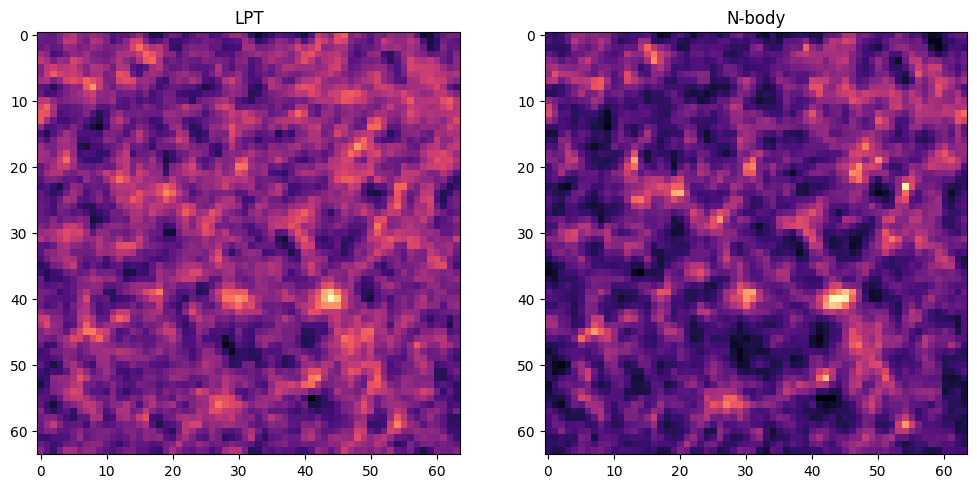

In [7]:
plt.figure(figsize=(12, 6))
plt.subplot(121)
plt.imshow(lpt_observation[10:].sum(axis=0), cmap="magma")
plt.title("LPT")
plt.subplot(122)
plt.imshow(observable[10:].sum(axis=0), cmap="magma")
plt.title("N-body")
plt.show()

### Gradient Evaluation  

We compute gradients of the N-body simulation with respect to cosmological parameters and analyze their sensitivity when moving away from the correct values.  


In [8]:
best_params = params
guess_params = Params(Omega_c=0.8, sigma8=0.8)


best_grad, _ = nbody_cosmo(
    best_params,
    initial_conditions,
    observable,
    ode_term,
    stepsize_controller=stepsize_controller,
    solver=Tsit5(),
)
guess_grad, _ = nbody_cosmo(
    guess_params,
    initial_conditions,
    observable,
    ode_term,
    stepsize_controller=stepsize_controller,
    solver=Tsit5(),
)

print(f"Gradient at the correct cosmology: {best_grad}")
print(f"Evaluating the gradient at the Correct Cosmology: {guess_grad}")

Gradient at the correct cosmology: Params(Omega_c=Array(0., dtype=float64, weak_type=True), sigma8=Array(0., dtype=float64, weak_type=True))
Evaluating the gradient at the Correct Cosmology: Params(Omega_c=Array(0.00205539, dtype=float64, weak_type=True), sigma8=Array(0., dtype=float64, weak_type=True))


#### Sensitivity to Initial Conditions  

We compute gradients of the N-body simulation with respect to initial conditions and analyze how they change when perturbing the initial field.  


In [9]:
best_ic = initial_conditions

cosmo = jc.Planck15(Omega_c=best_params.Omega_c, sigma8=best_params.sigma8)
pk = jc.power.linear_matter_power(cosmo, k)


def pk_fn(x):
    return jnp.interp(x.reshape([-1]), k, pk).reshape(x.shape)


# Create initial conditions
guess_ic = linear_field(mesh_shape, box_size, pk_fn, seed=jax.random.PRNGKey(42))

best_grad, _ = nbody_ic(
    best_params,
    best_ic,
    observable,
    ode_term,
    stepsize_controller=stepsize_controller,
    solver=Tsit5(),
)
guess_grad, _ = nbody_ic(
    best_params,
    guess_ic,
    observable,
    ode_term,
    stepsize_controller=stepsize_controller,
    solver=Tsit5(),
)

print(f"Gradient at the correct cosmology: Max {best_grad.max()} min {best_grad.min()}")
print(
    f"Evaluating the gradient at the Correct Cosmology: Max {guess_grad.max()} min {guess_grad.min()}"
)

Gradient at the correct cosmology: Max 0.0 min 0.0
Evaluating the gradient at the Correct Cosmology: Max 0.00026850172318211747 min -5.007068509940622e-05
